In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [6]:
sales=pd.read_csv('sales_data_large.csv')
sales.head(5)

,id,date,product_name,category,quantity_sold,unit_price,revenue,region
0,1,2025-04-16,Tablet,Electronics,11,300.0,3300.0,North
1,2,2025-04-19,Mouse,Accessories,5,20.0,100.0,North
2,3,2025-05-01,Headphones,Accessories,5,60.0,300.0,West
3,4,2025-04-27,Charger,Accessories,12,25.0,300.0,West
4,5,2025-04-07,Webcam,Accessories,2,80.0,160.0,West


In [7]:
conn=sqlite3.connect('sales.db')

In [8]:
sales.to_sql('sales',conn,if_exists='replace',index=False)

520

Checking the table and its schema

In [9]:
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query, conn)
tables

,name
0,sales


In [96]:
query="pragma table_info(sales);"
schema=pd.read_sql_query(query,conn)
schema

,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,0
1,1,date,TEXT,0,None,0
2,2,product_name,TEXT,0,None,0
3,3,category,TEXT,0,None,0
4,4,quantity_sold,INTEGER,0,None,0
5,5,unit_price,REAL,0,None,0
6,6,revenue,REAL,0,None,0
7,7,region,TEXT,0,None,0


Total revenue

In [92]:
query= "select sum(revenue) as Total_Revenue from sales;"
total_revenue=pd.read_sql_query(query,conn)
total_revenue

,Total_Revenue
0,1079780.0


Total Revenue and Quantity Sold by Product

In [50]:
query = "select product_name as product,sum(quantity_sold)as quantity,sum(revenue)as revenue " \
        "from sales " \
        "group by(product_name) " \
        "order by(revenue) desc;"

sales_by_product = pd.read_sql_query(query, conn)
sales_by_product


,product,quantity,revenue
0,Laptop,572,429000.0
1,Smartphone,556,278000.0
2,Tablet,545,163500.0
3,Monitor,453,90600.0
4,Webcam,503,40240.0
5,Headphones,513,30780.0
6,Charger,682,17050.0
7,Keyboard,479,14370.0
8,Mouse,503,10060.0
9,USB Cable,618,6180.0


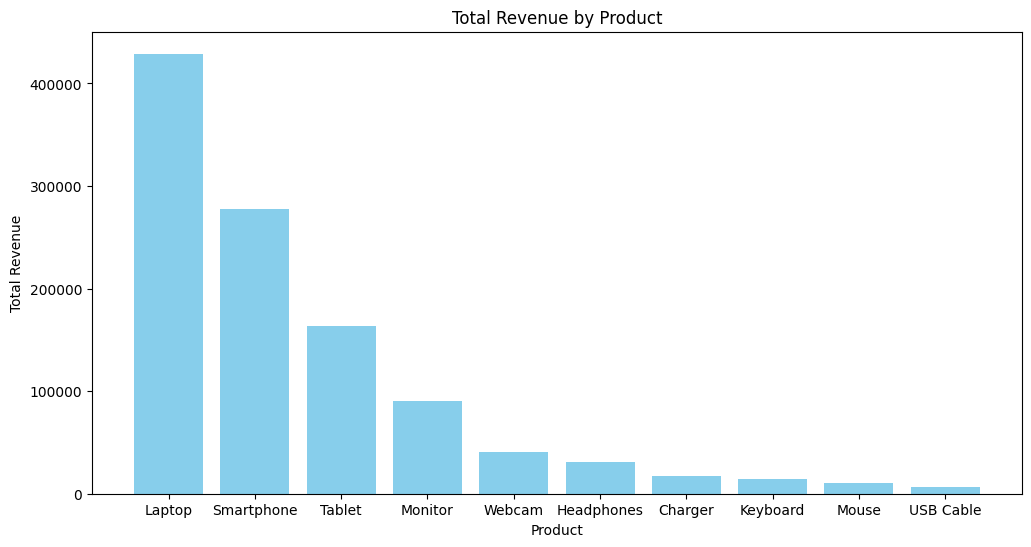

In [53]:
plt.figure(figsize=(12, 6))
plt.bar(sales_by_product['product'], sales_by_product['revenue'], color='skyblue')

plt.title('Total Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.show()

Sales by Category

In [54]:
query = "select category ,sum(quantity_sold)as quantity,sum(revenue)as revenue " \
        "from sales " \
        "group by(category) " \
        "order by(revenue) desc;"

sales_by_category = pd.read_sql_query(query, conn)
sales_by_category

,category,quantity,revenue
0,Electronics,2126,961100.0
1,Accessories,3298,118680.0


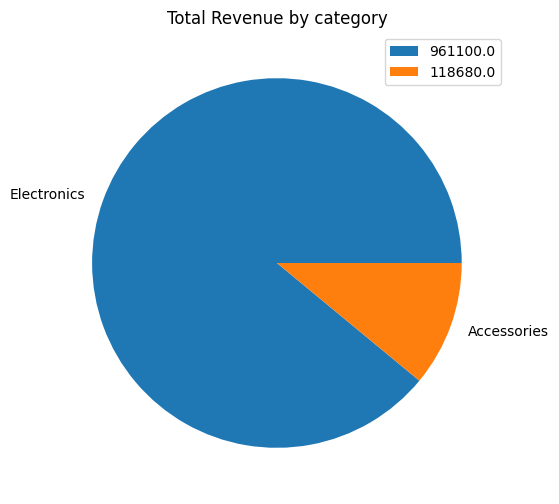

In [59]:
plt.figure(figsize=(12, 6))
plt.pie(sales_by_category['revenue'],  labels=sales_by_category['category'])
plt.title('Total Revenue by category')
plt.legend(sales_by_category['revenue'])
plt.show()

Revenue by Region

In [61]:
query="select region,sum(revenue) as revenue " \
"from sales " \
"group by region " \
"order by revenue desc;"
sales_by_region=pd.read_sql_query(query,conn)
sales_by_region

,region,revenue
0,West,295455.0
1,East,291220.0
2,South,261035.0
3,North,232070.0


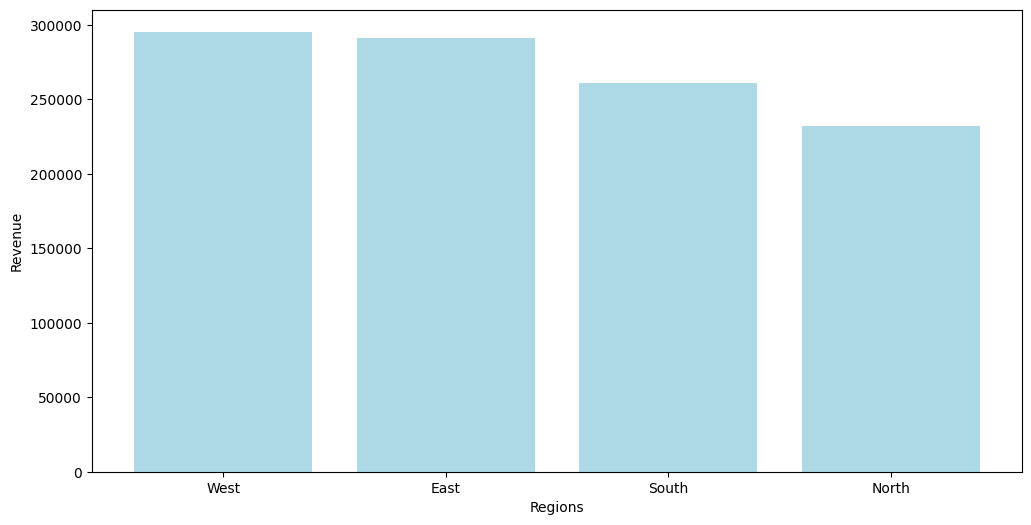

In [68]:
plt.figure(figsize=(12,6))
plt.bar(sales_by_region['region'], sales_by_region['revenue'], color='lightblue')
plt.xlabel('Regions')
plt.ylabel('Revenue')
plt.show()

Average Revenue per Transaction

In [71]:
query = 'select avg(revenue) as average_revenue_per_transaction ' \
'from sales;'
average_revenue_per_transaction=pd.read_sql_query(query,conn)
average_revenue_per_transaction

,average_revenue_per_transaction
0,2076.5


Monthly Revenue Trends

In [75]:
query="""select strftime('%Y-%m',date) as month 
,sum(revenue) as total_revenue 
from sales 
group by month 
order by total_revenue desc;"""
sales_by_month=pd.read_sql_query(query,conn)
sales_by_month

,month,total_revenue
0,2025-04,1051305.0
1,2025-05,28475.0


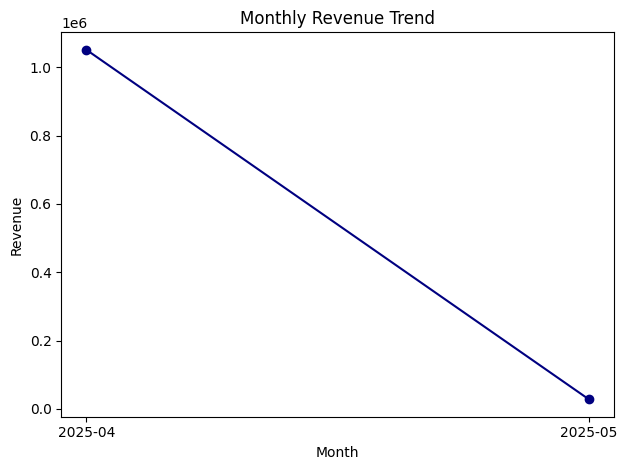

In [79]:
plt.plot(sales_by_month['month'], sales_by_month['total_revenue'], marker='o', color='navy')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

Top 5 Products by Quantity Sold

In [83]:
query="""select product_name ,sum(quantity_sold) as quantity 
from sales 
group by product_name 
order by quantity desc 
limit 5;"""
top5=pd.read_sql_query(query,conn)
top5

,product_name,quantity
0,Charger,682
1,USB Cable,618
2,Laptop,572
3,Smartphone,556
4,Tablet,545


Sales Performance by Day of the Week

In [85]:
query="""select 
case strftime('%w', date) 
when '0' then 'sunday' 
when '1' then 'monday' 
when '2' then 'tuesday' 
when '3' then 'wednesday' 
when '4' then 'thursday' 
when '5' then 'friday' 
when '6' then 'saturday' 
end as day_of_week, 
sum(revenue) as total_revenue 
from sales 
group by day_of_week 
order by total_revenue desc;
"""
sales_day_of_week=pd.read_sql_query(query,conn)
sales_day_of_week

,day_of_week,total_revenue
0,monday,210165.0
1,wednesday,192130.0
2,tuesday,162995.0
3,thursday,159515.0
4,saturday,121955.0
5,friday,119020.0
6,sunday,114000.0


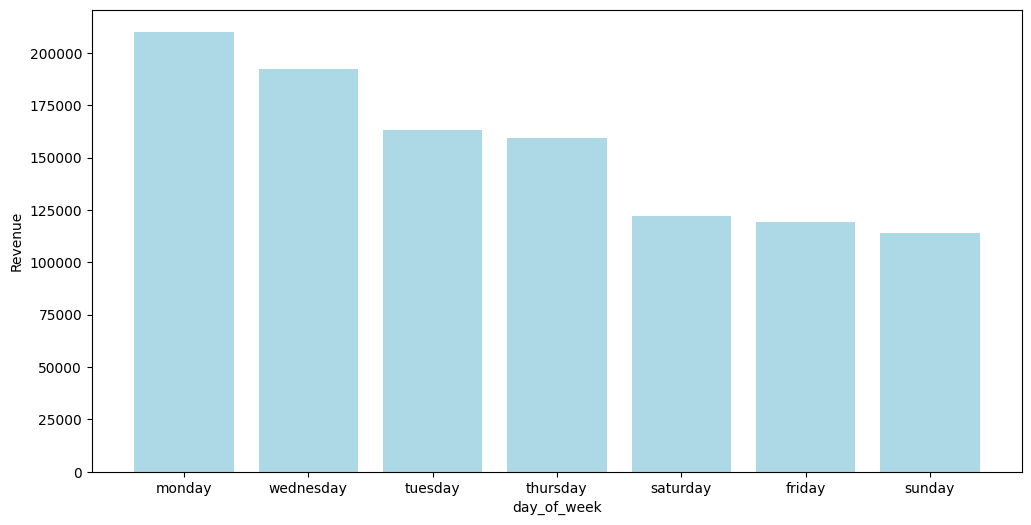

In [86]:
plt.figure(figsize=(12,6))
plt.bar(sales_day_of_week['day_of_week'], sales_day_of_week['total_revenue'], color='lightblue')
plt.xlabel('day_of_week')
plt.ylabel('Revenue')
plt.show()